# 11 · Regression through the time-series model

These are the app's simple and multiple Consumption regressions. Restart Kernel and Run All
constructs five frozen quarterly series, both ARIMAX models, and runs the saved Bayesian settings.
API reference: BestFit Verification `TimeSeriesAnalysis/ARIMAXAnalysisTests.cs` and
`Datasets/TimeSeriesData/RealTimeSeriesData.cs`. The actual observations are from this project's
frozen source; the Verification scenarios are not used as data or model settings.

In [2]:
from pathlib import Path
import sys
from time import perf_counter
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
print(load_bestfit())
from System import Array, DateTime, Double
from System.Collections.Generic import List
from Numerics.Data import TimeInterval, TimeSeries, SeriesOrdinate
from Numerics.Distributions import Uniform
from RMC.BestFit.Models import ARIMAX, Transform
from RMC.BestFit.Analyses import ARIMAXAnalysis
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Construct aligned quarterly observations

`Consumption` is the response. Income, Production, Savings and Unemployment are the only
available saved predictors. All 187 records run from 1970 Q1 to 2016 Q3. The dates are
retained exactly, so `SetCovariates` can align predictors by timestamp.

In [3]:
raw = load_raw("time-series-regression-example")
series = {}
for name in ("Consumption", "Income", "Production", "Savings", "Unemployment"):
    source = raw["series"][name]
    ts = TimeSeries(getattr(TimeInterval, source["attributes"]["TimeInterval"]))
    for row in source["records"]:
        ts.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(row["Index"]), float(row["Value"])))
    series[name] = ts
response_dates = [str(p.Index.ToString("o")) for p in series["Consumption"]]
assert all([str(p.Index.ToString("o")) for p in ts] == response_dates for ts in series.values())
display(pd.DataFrame([{"Series": name, "Observations": ts.Count,
                       "First": str(ts[0].Index.ToString("yyyy-MM-dd")),
                       "Last": str(ts[ts.Count-1].Index.ToString("yyyy-MM-dd"))}
                      for name, ts in series.items()]))
print(raw["source"])

,Series,Observations,First,Last
0,Consumption,187,1970-01-01,2016-07-01
1,Income,187,1970-01-01,2016-07-01
2,Production,187,1970-01-01,2016-07-01
3,Savings,187,1970-01-01,2016-07-01
4,Unemployment,187,1970-01-01,2016-07-01


{'bytes': 5373952, 'relative_path': 'examples/7-time-series-analysis/3-time-series-regression-example/time-series-regression-example.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': 'd84276fb50bcb6fc9bde46f361917abedada3398b3b5bacde42dfc01889a6115'}


## Configure the saved regression designs

These are ARIMAX(0,0,0) models with current-quarter predictors (`XOrderB=0`), intercept,
no transform, no seasonal or trend component, and the saved flat parameter priors plus
Jeffreys' scale rule. Both retain automatic training selection: 149 of 187 observations.
The tuples give the original parameter bounds and uniform prior limits. DEMCzs initializes
from these priors; the fitted coefficients will come from the newly computed chains.

In [4]:
cases = {
    "Simple Linear Regression": {
        "covariates": ["Income"], "chains": 6, "thin": 30, "initial": 300,
        "jump": .97163093130399403,
        "parameters": [(.01, 10), (-10, 10), (1.11022302462516e-16, 10)]},
    "Multiple Linear Regression": {
        "covariates": ["Income", "Production", "Savings", "Unemployment"],
        "chains": 12, "thin": 60, "initial": 600, "jump": .68704682033565467,
        "parameters": [(.01, 10), (-10, 10), (-10, 10), (-10, 10), (-10, 10),
                       (1.11022302462516e-16, 10)]},
}
models = {}
for name, settings in cases.items():
    model = ARIMAX(series["Consumption"])
    model.TransformType = getattr(Transform, "None")
    model.IncludeIntercept = True
    model.IncludeSeasonality = False
    model.TrendType = getattr(ARIMAX.Trend, "None")
    model.AROrderP = 0
    model.DiffOrderD = 0
    model.MAOrderQ = 0
    model.XOrderB = 0
    model.CovariateExtension = ARIMAX.CovariateExtensionMethod.BlockBootstrap
    covariates = List[TimeSeries]()
    for covariate_name in settings["covariates"]:
        covariates.Add(series[covariate_name])
    model.SetCovariates(covariates)
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    model.UseDefaultTrainingSteps = True
    assert model.TrainingTimeSteps == 149
    assert model.Parameters.Count == len(settings["parameters"])
    for parameter, (lower, upper) in zip(model.Parameters, settings["parameters"]):
        parameter.LowerBound = lower
        parameter.UpperBound = upper
        parameter.PriorDistribution = Uniform(lower, upper)
        parameter.IsPositive = parameter.Name.startswith("Scale")
        parameter.IsFixed = False
    models[name] = model
display(pd.DataFrame([{"Analysis": name, "Predictors": ", ".join(c["covariates"]),
                       "Training": models[name].TrainingTimeSteps,
                       "Observed holdout": models[name].TimeSeries.Count - models[name].TrainingTimeSteps,
                       "Future steps": 30}
                      for name, c in cases.items()]))

,Analysis,Predictors,Training,Observed holdout,Future steps
0,Simple Linear Regression,Income,149,38,30
1,Multiple Linear Regression,"Income, Production, Savings, Unemployment",149,38,30


## Run each saved Bayesian analysis

`analysis.ForecastingTimeSteps=30` extends beyond the observed response; the 38 observed
holdout quarters remain a separate assessment window. `BlockBootstrap` extends each predictor
independently, retaining within-series blocks but not their joint dependence. Deterministic
predictions extend predictors with their means; predictive uncertainty includes bootstrap draws.

In [5]:
analyses, timings = {}, {}
for name, settings in cases.items():
    analysis = ARIMAXAnalysis(models[name])
    analysis.ForecastingTimeSteps = 30
    bayes = analysis.BayesianAnalysis
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.UseSimulationDefaults = True
    bayes.UseAdvancedSimulationDefaults = True
    bayes.NumberOfChains = settings["chains"]
    bayes.ThinningInterval = settings["thin"]
    bayes.WarmupIterations = 1750
    bayes.Iterations = 3500
    bayes.PRNGSeed = 12345
    bayes.InitialIterations = settings["initial"]
    bayes.Jump = settings["jump"]
    bayes.JumpThreshold = .1
    bayes.SnookerThreshold = .1
    bayes.Noise = 1e-12
    bayes.Scale = 5.6644
    bayes.Beta = .05
    bayes.MaxTreeDepth = 10
    bayes.CredibleIntervalWidth = .9
    bayes.OutputLength = 10000
    bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name] = analysis
    record_run(name, analysis, timings[name], raw=raw, model=models[name])

Simple Linear Regression: completed in 3.26 s. Execution alone does not establish convergence or scientific acceptance.


Multiple Linear Regression: completed in 7.92 s. Execution alone does not establish convergence or scientific acceptance.


## Independently check the fitted regression arithmetic

With AR=MA=d=0 and no transformation, the training mean is X beta and errors are Gaussian.
Compute both from the raw rows and the coefficients just estimated, then compare with BestFit's
residuals and data likelihood. The absolute 1e-9 tolerance allows floating-point summation error;
it is not a tolerance on statistical accuracy, MCMC convergence or future forecasts.

In [6]:
arithmetic_checks = []
for name, model in models.items():
    n = model.TrainingTimeSteps
    y = np.array([float(row["Value"]) for row in raw["series"]["Consumption"]["records"][:n]])
    design = np.column_stack([np.ones(n)] + [
        [float(row["Value"]) for row in raw["series"][predictor]["records"][:n]]
        for predictor in cases[name]["covariates"]])
    parameters = np.array([float(p.Value) for p in model.Parameters])
    expected_residuals = y - design @ parameters[:-1]
    sigma = parameters[-1]
    expected_log_likelihood = float(np.sum(-np.log(sigma * np.sqrt(2 * np.pi))
                                           - .5 * (expected_residuals / sigma)**2))
    managed_parameters = Array[Double](parameters.tolist())
    np.testing.assert_allclose(list(model.Residuals(managed_parameters)), expected_residuals,
                               rtol=1e-12, atol=1e-9)
    np.testing.assert_allclose(model.DataLogLikelihood(managed_parameters), expected_log_likelihood,
                               rtol=1e-12, atol=1e-9)
    arithmetic_checks.append({"Case": name, "Independent Gaussian data log-likelihood": expected_log_likelihood,
                              "Checked training rows": n})
display(pd.DataFrame(arithmetic_checks))

,Case,Independent Gaussian data log-likelihood,Checked training rows
0,Simple Linear Regression,-134.848600,149
1,Multiple Linear Regression,-51.255781,149


## Compare fits for the same response and inspect mixing

The two cases share Consumption observations and ARIMAX likelihood, so their DIC values can
be compared. Lower fit criteria do not establish causal effects or guarantee future accuracy.
R-hat and ESS below come from these new chains. A completed chain is not convergence acceptance.

In [7]:
fit_rows, parameter_rows = [], []
for name, analysis in analyses.items():
    result = analysis.AnalysisResults
    fit_rows.append({"Analysis": name, "AIC": float(result.AIC), "BIC": float(result.BIC),
                     "DIC": float(result.DIC), "RMSE": float(result.RMSE),
                     "Seconds": timings[name]})
    for parameter, estimate in zip(models[name].Parameters, analysis.BayesianAnalysis.Results.ParameterResults):
        stats = estimate.SummaryStatistics
        parameter_rows.append({"Analysis": name, "Parameter": str(parameter.Name),
                               "Posterior mean": float(stats.Mean),
                               "R-hat": float(stats.Rhat), "ESS": float(stats.ESS)})
display(pd.DataFrame(fit_rows))
display(pd.DataFrame(parameter_rows))

,Analysis,AIC,BIC,DIC,RMSE,Seconds
0,Simple Linear Regression,275.670652,284.682491,275.582088,0.598081,3.264052
1,Multiple Linear Regression,114.500283,132.523961,114.447139,0.341147,7.918934


,Analysis,Parameter,Posterior mean,R-hat,ESS
0,Simple Linear Regression,Intercept (μ),0.581308,1.000205,9861.323044
1,Simple Linear Regression,Covariate (β₁),0.324730,1.000181,9808.098843
2,Simple Linear Regression,Scale (σ),0.604545,1.000303,8862.552937
3,Multiple Linear Regression,Intercept (μ),0.305089,1.000027,9733.598249
4,Multiple Linear Regression,Covariate (β₁),0.703551,0.999981,9703.286511
5,Multiple Linear Regression,Covariate (β₂),0.036723,1.000121,9624.566865
6,Multiple Linear Regression,Covariate (β₃),-0.047047,0.999976,9936.412438
7,Multiple Linear Regression,Covariate (β₄),-0.274178,1.000109,9852.307926
8,Multiple Linear Regression,Scale (σ),0.348938,1.000005,9901.605697


## Fresh prediction and residual views

The prediction plot labels the training, observed holdout and future parts on a date axis.
Residual structure motivates a separate model question; these examples retain their zero
AR, differencing and MA orders. Compare predictive bands and residual dependence together.

Simple Linear Regression


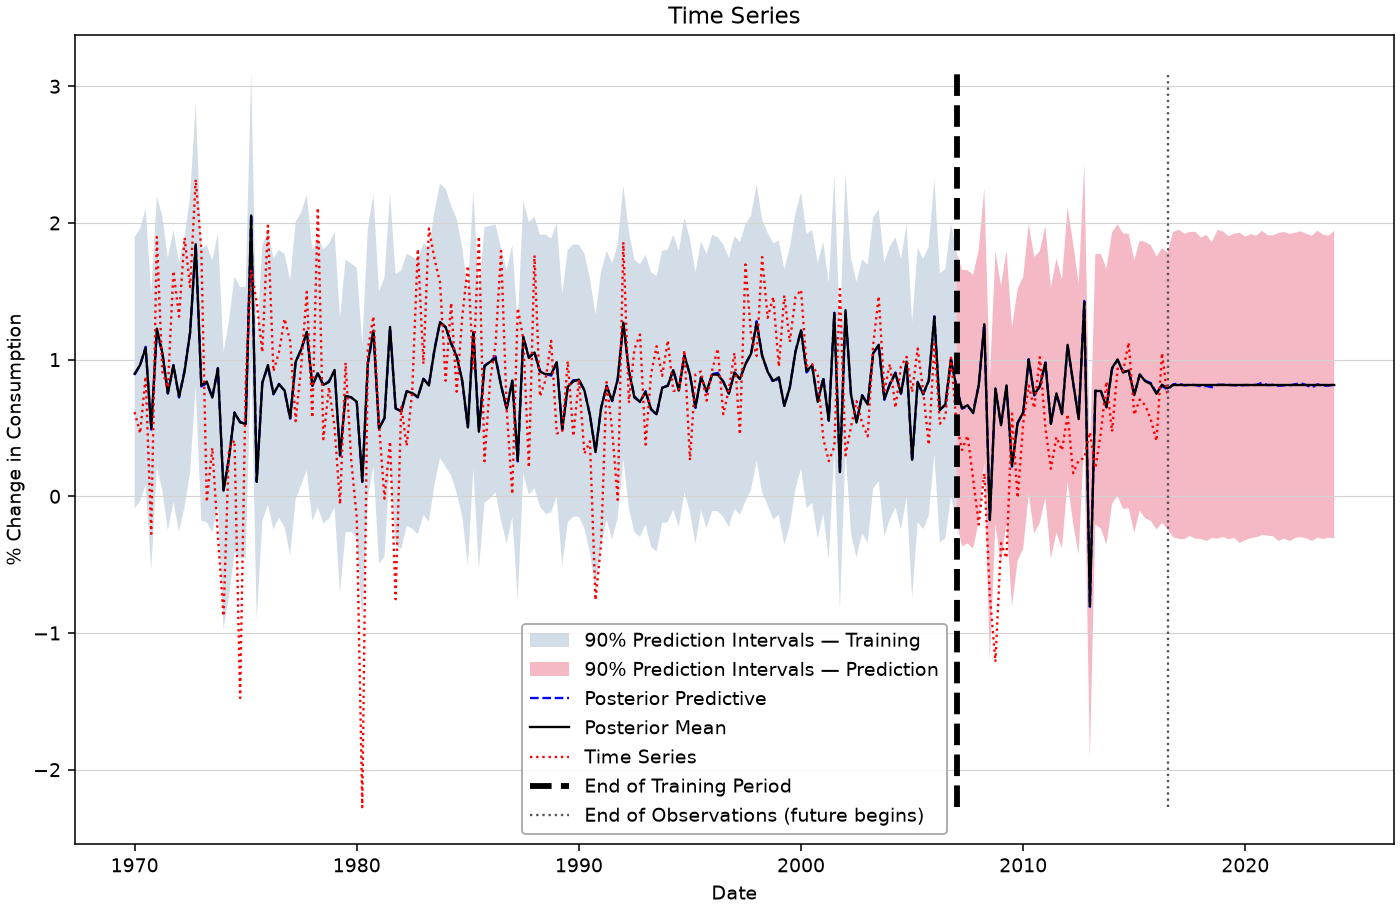

Multiple Linear Regression


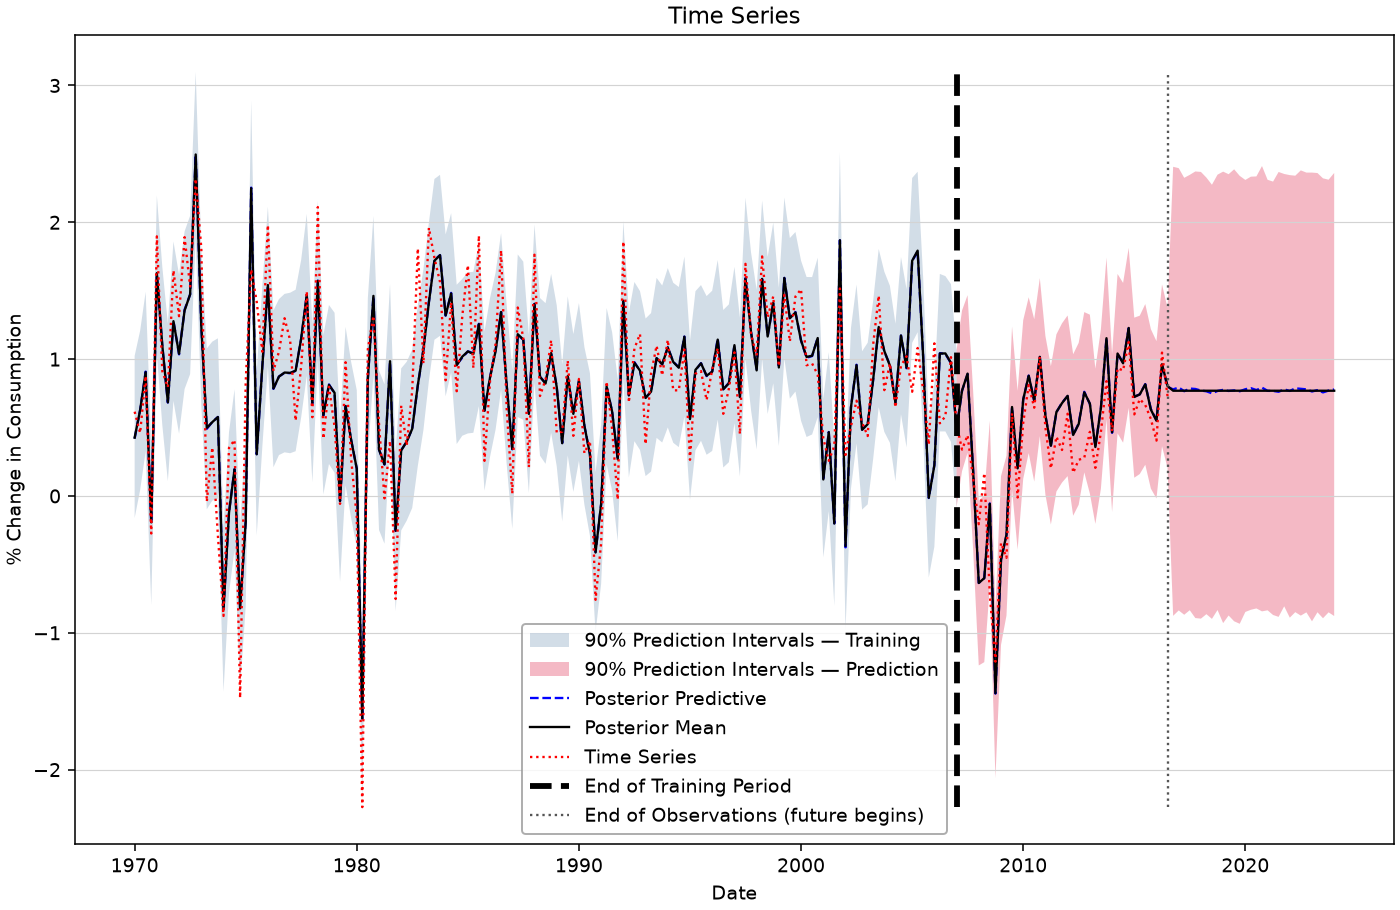

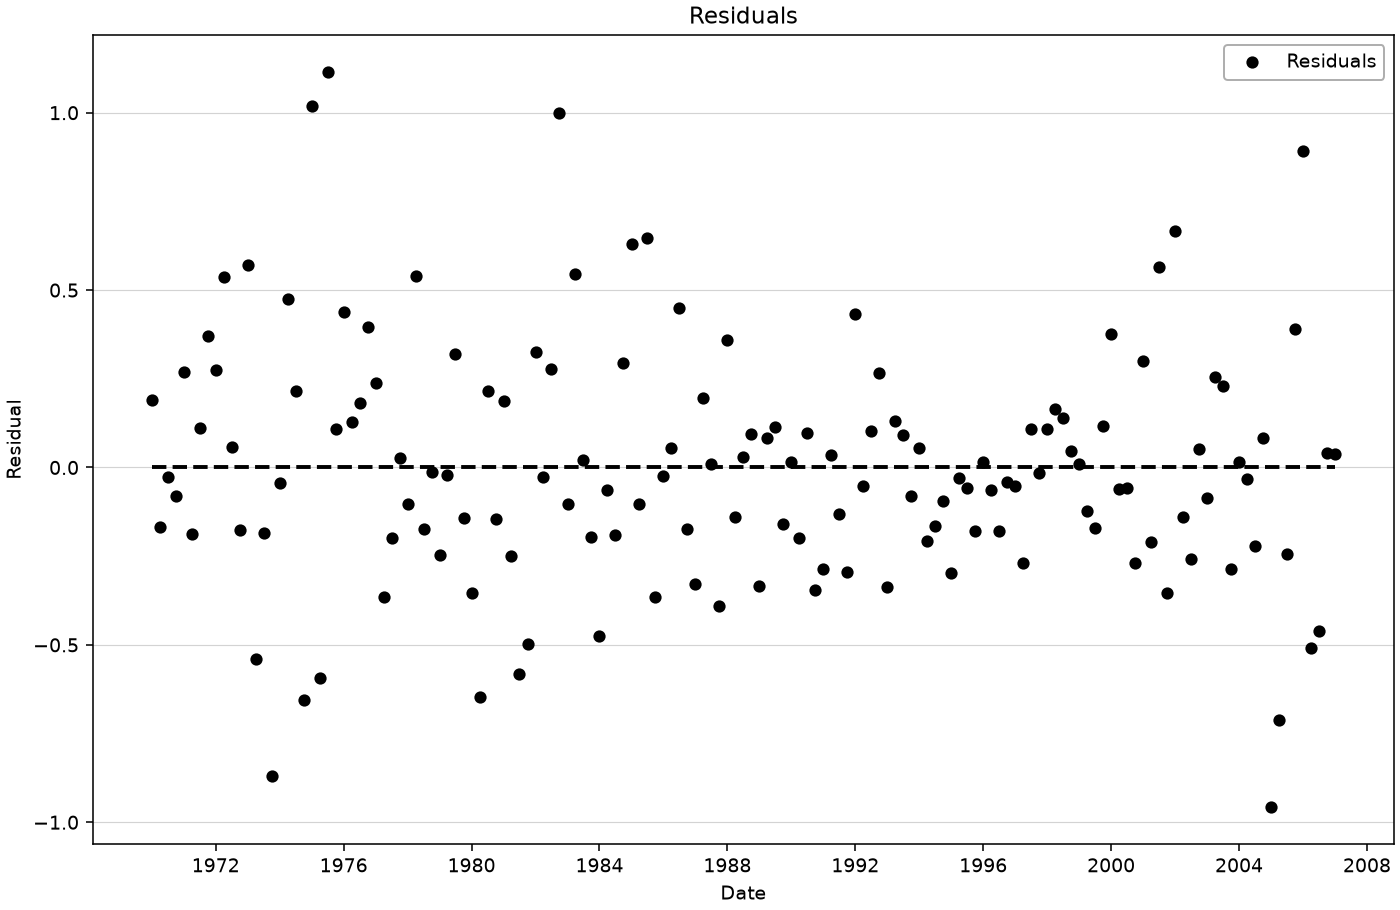

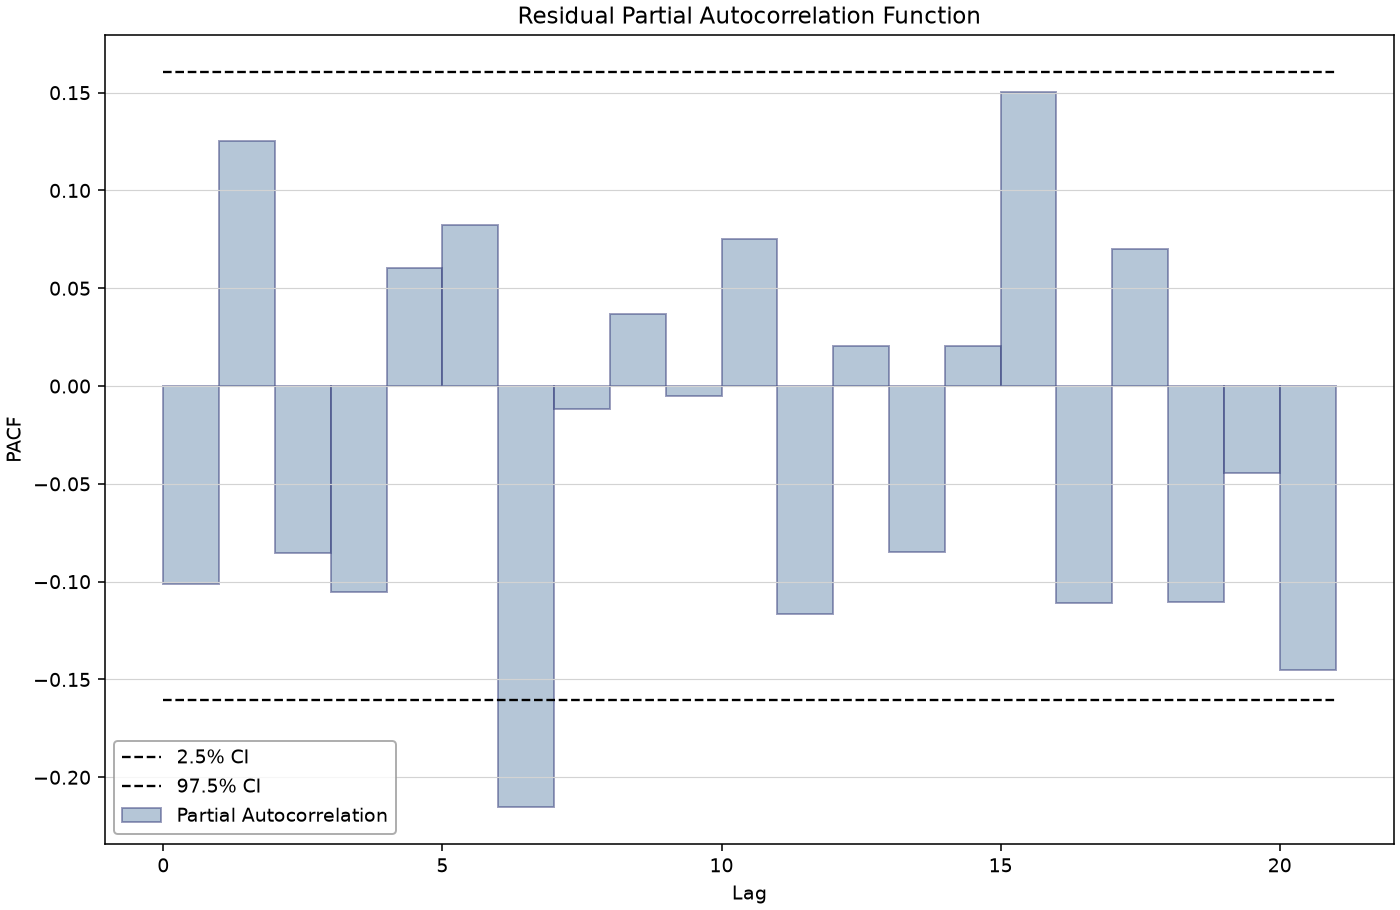

In [8]:
from bestfit_plots.adapters.common import line
figures = {}
for name, analysis in analyses.items():
    context = plot_context(analysis, models[name], name=name, raw=raw,
                           metadata=raw["series"]["Consumption"]["metadata"])
    figures[name] = plots(context)
    # Mark where the observed holdout ends and the 30 future quarters begin.
    prediction = figures[name]["series"]
    training_marker = next(s for s in prediction["series"] if s["name"] == "End of Training Period")
    observation_end = str(series["Consumption"][series["Consumption"].Count - 1].Index.ToString("yyyy-MM-ddTHH:mm:ss"))
    prediction["series"].append(line("End of Observations (future begins)",
                                      [observation_end, observation_end], training_marker["y"],
                                      color="#555555", linestyle=":"))
    print(name)
    show(figures[name]["series"])
show(figures["Multiple Linear Regression"]["residuals"])
show(figures["Multiple Linear Regression"]["residual_pacf"])

**Adapt this example:** use your own aligned response and predictor series, choose the model
and forecast horizon, and inspect mixing and held-out behavior before interpreting coefficients.